# Notebook 02 — Front Detection Dataset Audit

**Purpose:** restore one fixed Front dataset version from Roboflow only when it is absent, then audit its YOLO structure, images, labels, class balance, bounding boxes, and duplicate leakage. No upload, dataset mutation, training, Top-camera work, or credential persistence is performed.

## 1. Experiment metadata and PROJECT_ROOT

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import os, platform, sys, time
import torch

EXPERIMENT_ID = 'FRONT_DATASET_AUDIT_001'
STARTED_AT = datetime.now(timezone.utc)
START_TIME = time.perf_counter()
def find_project_root(start):
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / marker).exists() for marker in ('AGENTS.md', 'FISH_AI_PROJECT_WORKFLOW.md', '.git')):
            return candidate
    raise RuntimeError(f'Cannot resolve PROJECT_ROOT from {start.resolve()}')

PROJECT_ROOT = find_project_root(Path.cwd())
CONDA_ENV = os.environ.get('CONDA_DEFAULT_ENV', 'not set')
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = 'cuda:0' if CUDA_AVAILABLE else 'cpu'
GPU_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else 'Not available'
print(f'Experiment ID: {EXPERIMENT_ID}')
print(f'Datetime: {STARTED_AT.isoformat()}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Python executable: {sys.executable}')
print(f'Conda environment: {CONDA_ENV}')
print(f'Device: {DEVICE}')
print(f'GPU: {GPU_NAME}')
assert CONDA_ENV == 'fish', 'Select the fish kernel before Run All.'

Experiment ID: FRONT_DATASET_AUDIT_001
Datetime: 2026-08-17T05:15:22.722378+00:00
PROJECT_ROOT: /home/diy-hus/fish
Python executable: /home/diy-hus/miniconda3/envs/fish/bin/python
Conda environment: fish
Device: cuda:0
GPU: NVIDIA GeForce RTX 3050


## 2. Dependency check

In [2]:
import importlib.util, importlib.metadata
ROBOFLOW_PACKAGE_AVAILABLE = importlib.util.find_spec('roboflow') is not None
print(f'roboflow package available: {ROBOFLOW_PACKAGE_AVAILABLE}')
if ROBOFLOW_PACKAGE_AVAILABLE:
    print(f'roboflow version: {importlib.metadata.version("roboflow")}')
else:
    print('roboflow package is missing')
    raise ModuleNotFoundError('roboflow package is missing; ask Codex for the approved minimal installation step.')

roboflow package available: True
roboflow version: 1.4.0


## 3. Load and print CONFIG

In [3]:
import yaml
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'data_sources.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    DATA_SOURCES_CONFIG = yaml.safe_load(handle)
FRONT_CONFIG = DATA_SOURCES_CONFIG['sources']['labeled_detection_dataset']['front']
WORKSPACE_ID = FRONT_CONFIG.get('workspace')
PROJECT_ID = FRONT_CONFIG.get('project')
VERSION_NUMBER = FRONT_CONFIG.get('version')
EXPORT_FORMAT = FRONT_CONFIG.get('format')
DATASET_ROOT = PROJECT_ROOT / FRONT_CONFIG['local_root']
print('CONFIG — FRONT ROBOFLOW DATASET')
for key in ('source', 'workspace', 'project', 'version', 'format', 'local_root'):
    print(f'{key}: {FRONT_CONFIG.get(key)}')
missing_config = [name for name, value in {'workspace': WORKSPACE_ID, 'project': PROJECT_ID, 'version': VERSION_NUMBER, 'format': EXPORT_FORMAT}.items() if value in (None, '')]
if missing_config:
    raise ValueError(f'Front dataset config is incomplete; fill these fields in configs/data_sources.yaml: {missing_config}')
if not isinstance(VERSION_NUMBER, int) or VERSION_NUMBER <= 0:
    raise ValueError('Front dataset version must be a fixed positive integer.')

CONFIG — FRONT ROBOFLOW DATASET
source: roboflow
workspace: phys-hus
project: fish_front_detection
version: 1
format: yolov8
local_root: data/roboflow/front_detect_v1


## 4. Check local dataset before authentication

In [4]:
def local_dataset_state(root):
    required = [root / 'data.yaml', root / 'train' / 'images', root / 'train' / 'labels', root / 'valid' / 'images', root / 'valid' / 'labels']
    complete = all(path.exists() for path in required)
    if complete:
        return 'FOUND', []
    if root.exists() and any(root.iterdir()):
        return 'PARTIAL_DATASET_FOUND', [str(path.relative_to(PROJECT_ROOT)) for path in required if not path.exists()]
    return 'MISSING', [str(path.relative_to(PROJECT_ROOT)) for path in required]

DATASET_LOCAL, missing_structure = local_dataset_state(DATASET_ROOT)
print(f'DATASET_LOCAL = {DATASET_LOCAL}')
print(f'Dataset root: {DATASET_ROOT.relative_to(PROJECT_ROOT)}')
if missing_structure:
    print(f'Missing structure: {missing_structure}')
if DATASET_LOCAL == 'PARTIAL_DATASET_FOUND':
    raise RuntimeError('PARTIAL_DATASET_FOUND: destination will not be deleted or overwritten. USER must inspect it manually.')

DATASET_LOCAL = FOUND
Dataset root: data/roboflow/front_detect_v1


## 5. Restore the fixed Roboflow version only when missing

In [5]:
DOWNLOAD_DATETIME = None
if DATASET_LOCAL == 'FOUND':
    print('Local dataset is complete; authentication and download are skipped.')
else:
    from getpass import getpass
    from roboflow import Roboflow
    DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)
    print('ROBOFLOW DATASET RESTORE')
    print(f'Workspace: {WORKSPACE_ID}')
    print(f'Project: {PROJECT_ID}')
    print(f'Version: {VERSION_NUMBER}')
    print(f'Format: {EXPORT_FORMAT}')
    print(f'Destination: {DATASET_ROOT.relative_to(PROJECT_ROOT)}')
    api_key = getpass('Enter Roboflow Private API Key: ')
    download_start = time.perf_counter()
    try:
        rf = Roboflow(api_key=api_key)
        project = rf.workspace(WORKSPACE_ID).project(PROJECT_ID)
        dataset_version = project.version(VERSION_NUMBER)
        dataset_version.download(model_format=EXPORT_FORMAT, location=str(DATASET_ROOT), overwrite=False)
        DOWNLOAD_DATETIME = datetime.now(timezone.utc).isoformat()
    except Exception:
        raise RuntimeError('Roboflow authentication or download failed. Verify the private key and fixed dataset metadata; no credential was logged.') from None
    finally:
        del api_key
    print('Download completed')
    print(f'Dataset root: {DATASET_ROOT.relative_to(PROJECT_ROOT)}')
    print(f'Elapsed time: {time.perf_counter() - download_start:.2f} s')
DATASET_LOCAL, missing_structure = local_dataset_state(DATASET_ROOT)
if DATASET_LOCAL != 'FOUND':
    raise RuntimeError(f'Dataset restore did not produce the required structure: {missing_structure}')

Local dataset is complete; authentication and download are skipped.


## 6. Validate data.yaml and split structure

In [6]:
import hashlib, json, math, re
import cv2, numpy as np, pandas as pd
from IPython.display import display
DATA_YAML_PATH = DATASET_ROOT / 'data.yaml'
with DATA_YAML_PATH.open('r', encoding='utf-8') as handle:
    DATA_YAML = yaml.safe_load(handle)
if not isinstance(DATA_YAML, dict):
    raise ValueError('data.yaml must contain a mapping.')
CLASS_NAMES_RAW = DATA_YAML.get('names')
if isinstance(CLASS_NAMES_RAW, list):
    CLASS_NAMES = {index: name for index, name in enumerate(CLASS_NAMES_RAW)}
elif isinstance(CLASS_NAMES_RAW, dict):
    CLASS_NAMES = {int(key): value for key, value in CLASS_NAMES_RAW.items()}
else:
    raise ValueError('data.yaml names must be a list or mapping.')
NC = int(DATA_YAML.get('nc', len(CLASS_NAMES)))
if NC != len(CLASS_NAMES):
    raise ValueError(f'nc={NC} does not match class-name count={len(CLASS_NAMES)}')
print(f'data.yaml: {DATA_YAML_PATH.relative_to(PROJECT_ROOT)}')
for key in ('train', 'val', 'test', 'nc', 'names'):
    print(f'{key}: {DATA_YAML.get(key)}')
SPLITS = {'train': DATASET_ROOT / 'train', 'valid': DATASET_ROOT / 'valid'}
if (DATASET_ROOT / 'test').exists():
    SPLITS['test'] = DATASET_ROOT / 'test'
for split, root in SPLITS.items():
    for child in ('images', 'labels'):
        if not (root / child).is_dir():
            raise FileNotFoundError(f'Missing required directory: {(root / child).relative_to(PROJECT_ROOT)}')
    print(f'{split}: structure OK')

data.yaml: data/roboflow/front_detect_v1/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 1
names: ['Ca']
train: structure OK
valid: structure OK


## 7. Discover images and labels

In [7]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
split_files = {}
for split, root in SPLITS.items():
    images = sorted(path for path in (root / 'images').rglob('*') if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)
    labels = sorted((root / 'labels').rglob('*.txt'))
    image_by_stem = {path.relative_to(root / 'images').with_suffix(''): path for path in images}
    label_by_stem = {path.relative_to(root / 'labels').with_suffix(''): path for path in labels}
    missing_labels = sorted(str(key) for key in image_by_stem.keys() - label_by_stem.keys())
    orphan_labels = sorted(str(key) for key in label_by_stem.keys() - image_by_stem.keys())
    split_files[split] = {'images': images, 'labels': labels, 'missing_labels': missing_labels, 'orphan_labels': orphan_labels}
    print(f'{split}: images={len(images)}, labels={len(labels)}, missing_labels={len(missing_labels)}, orphan_labels={len(orphan_labels)}')

train: images=1015, labels=1015, missing_labels=0, orphan_labels=0
valid: images=254, labels=254, missing_labels=0, orphan_labels=0


## 8. Audit YOLO labels

In [8]:
label_errors, boundary_warnings, box_records, split_stats = [], [], [], []
annotation_format_stats, mixed_format_records = [], []
error_columns = ['split', 'image_path', 'label_path', 'line_number', 'error_type', 'raw_label', 'class_id', 'x_center', 'y_center', 'width', 'height']
for split, files in split_files.items():
    empty_labels = 0
    split_bbox_rows = split_polygon_rows = 0
    split_bbox_files = split_polygon_files = split_mixed_files = 0
    split_root = SPLITS[split]
    images_by_stem = {path.relative_to(split_root / 'images').with_suffix(''): path for path in files['images']}
    for index, label_path in enumerate(files['labels'], 1):
        if index % 200 == 0 or index == len(files['labels']):
            print(f'Auditing labels {split}: {index}/{len(files["labels"])}')
        relative_label_path = str(label_path.relative_to(DATASET_ROOT))
        label_stem = label_path.relative_to(split_root / 'labels').with_suffix('')
        image_path = images_by_stem.get(label_stem)
        relative_image_path = str(image_path.relative_to(DATASET_ROOT)) if image_path else None
        lines = label_path.read_text(encoding='utf-8', errors='replace').splitlines()
        if not any(line.strip() for line in lines):
            empty_labels += 1
        file_bbox_rows = file_polygon_rows = file_unknown_rows = 0
        for line_number, line in enumerate(lines, 1):
            if not line.strip():
                continue
            parts = line.split()
            row_format = 'bbox' if len(parts) == 5 else ('polygon' if len(parts) >= 7 and len(parts) % 2 == 1 else 'unknown')
            if row_format == 'bbox':
                file_bbox_rows += 1; split_bbox_rows += 1
            elif row_format == 'polygon':
                file_polygon_rows += 1; split_polygon_rows += 1
            else:
                file_unknown_rows += 1
            reason, parsed = None, []
            try:
                parsed = list(map(float, parts))
            except ValueError:
                reason = 'non_numeric_value'
            class_value = parsed[0] if parsed else None
            x = y = width = height = None
            if reason is None and not all(math.isfinite(value) for value in parsed): reason = 'nan_or_inf'
            elif reason is None and row_format == 'unknown': reason = 'invalid_field_structure'
            elif reason is None and (not class_value.is_integer() or not 0 <= int(class_value) < NC): reason = 'invalid_class_id'
            elif reason is None and row_format == 'bbox':
                _, x, y, width, height = parsed
                if not 0 <= x <= 1: reason = 'x_center_out_of_range'
                elif not 0 <= y <= 1: reason = 'y_center_out_of_range'
                elif not 0 < width <= 1: reason = 'width_out_of_range'
                elif not 0 < height <= 1: reason = 'height_out_of_range'
            elif reason is None and row_format == 'polygon':
                coordinates = parsed[1:]
                if len(coordinates) < 6 or len(coordinates) % 2: reason = 'invalid_polygon_structure'
                elif not all(0 <= value <= 1 for value in coordinates): reason = 'polygon_coordinate_out_of_range'
                else:
                    x_points, y_points = coordinates[0::2], coordinates[1::2]
                    xmin, xmax, ymin, ymax = min(x_points), max(x_points), min(y_points), max(y_points)
                    x, y = (xmin + xmax) / 2, (ymin + ymax) / 2
                    width, height = xmax - xmin, ymax - ymin
            if reason is None:
                if row_format == 'bbox':
                    extents = {'crosses_left_edge': x - width / 2 < 0, 'crosses_right_edge': x + width / 2 > 1, 'crosses_top_edge': y - height / 2 < 0, 'crosses_bottom_edge': y + height / 2 > 1}
                    for subtype, crosses_edge in extents.items():
                        if crosses_edge: boundary_warnings.append({'split': split, 'image_path': relative_image_path, 'label_path': relative_label_path, 'line_number': line_number, 'warning_type': 'BOUNDARY_WARNING', 'subtype': subtype, 'x_center': x, 'y_center': y, 'width': width, 'height': height})
                box_records.append({'split': split, 'label_path': relative_label_path, 'annotation_format': row_format, 'class_id': int(class_value), 'x_center': x, 'y_center': y, 'bbox_width': width, 'bbox_height': height, 'bbox_area': width * height})
            else:
                label_errors.append({'split': split, 'image_path': relative_image_path, 'label_path': relative_label_path, 'line_number': line_number, 'error_type': reason, 'raw_label': line, 'class_id': class_value, 'x_center': x, 'y_center': y, 'width': width, 'height': height})
        if file_bbox_rows and file_polygon_rows:
            split_mixed_files += 1
            mixed_format_records.append({'split': split, 'label_path': relative_label_path, 'image_path': relative_image_path, 'bbox_rows': file_bbox_rows, 'polygon_rows': file_polygon_rows, 'total_rows': file_bbox_rows + file_polygon_rows})
        elif file_bbox_rows and not file_unknown_rows: split_bbox_files += 1
        elif file_polygon_rows and not file_unknown_rows: split_polygon_files += 1
    annotation_format_stats.append({'split': split, 'bbox_rows': split_bbox_rows, 'polygon_rows': split_polygon_rows, 'bbox_files': split_bbox_files, 'polygon_files': split_polygon_files, 'mixed_format_files': split_mixed_files})
    split_stats.append({'split': split, 'n_images': len(files['images']), 'n_label_files': len(files['labels']), 'n_missing_labels': len(files['missing_labels']), 'n_orphan_labels': len(files['orphan_labels']), 'n_empty_labels': empty_labels, 'n_boxes': sum(record['split'] == split for record in box_records)})
split_summary = pd.DataFrame(split_stats)
annotation_format_summary = pd.DataFrame(annotation_format_stats)
split_summary = split_summary.merge(annotation_format_summary, on='split', how='left')
mixed_format_files_df = pd.DataFrame(mixed_format_records, columns=['split', 'label_path', 'image_path', 'bbox_rows', 'polygon_rows', 'total_rows'])
label_errors_df = pd.DataFrame(label_errors, columns=error_columns)
boundary_warnings_df = pd.DataFrame(boundary_warnings, columns=['split', 'image_path', 'label_path', 'line_number', 'warning_type', 'subtype', 'x_center', 'y_center', 'width', 'height'])
boxes_df = pd.DataFrame(box_records)
display(split_summary)
display(annotation_format_summary)
print(f'True invalid label rows: {len(label_errors_df)}')
print(f'Boundary warnings: {len(boundary_warnings_df)} across {boundary_warnings_df["label_path"].nunique() if len(boundary_warnings_df) else 0} images')
print(f'Mixed-format label files: {len(mixed_format_files_df)}')

Auditing labels train: 200/1015
Auditing labels train: 400/1015
Auditing labels train: 600/1015
Auditing labels train: 800/1015
Auditing labels train: 1000/1015
Auditing labels train: 1015/1015
Auditing labels valid: 200/254
Auditing labels valid: 254/254


,split,n_images,n_label_files,n_missing_labels,n_orphan_labels,n_empty_labels,n_boxes,bbox_rows,polygon_rows,bbox_files,polygon_files,mixed_format_files
0,train,1015,1015,0,0,0,3888,3847,41,1006,9,0
1,valid,254,254,0,0,0,995,985,10,251,3,0


,split,bbox_rows,polygon_rows,bbox_files,polygon_files,mixed_format_files
0,train,3847,41,1006,9,0
1,valid,985,10,251,3,0


True invalid label rows: 0
Boundary warnings: 0 across 0 images
Mixed-format label files: 0


## 9. Validate images and resolution distribution

In [9]:
image_records, corrupt_images = [], []
for split, files in split_files.items():
    for index, image_path in enumerate(files['images'], 1):
        if index % 100 == 0 or index == len(files['images']):
            print(f'Auditing images {split}: {index}/{len(files["images"])}')
        image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
        if image is None:
            corrupt_images.append({'split': split, 'image_path': str(image_path.relative_to(DATASET_ROOT)), 'reason': 'opencv_read_failed'})
            continue
        height, width = image.shape[:2]
        channels = 1 if image.ndim == 2 else image.shape[2]
        image_records.append({'split': split, 'image_path': str(image_path.relative_to(DATASET_ROOT)), 'extension': image_path.suffix.lower(), 'width': width, 'height': height, 'channels': channels})
image_metadata = pd.DataFrame(image_records)
corrupt_images_df = pd.DataFrame(corrupt_images, columns=['split', 'image_path', 'reason'])
print(f'Corrupt images: {len(corrupt_images_df)}')
if len(image_metadata):
    display(image_metadata.groupby(['split', 'width', 'height', 'channels']).size().rename('count').reset_index().head(20))

Auditing images train: 100/1015
Auditing images train: 200/1015
Auditing images train: 300/1015
Auditing images train: 400/1015
Auditing images train: 500/1015
Auditing images train: 600/1015
Auditing images train: 700/1015
Auditing images train: 800/1015
Auditing images train: 900/1015
Auditing images train: 1000/1015
Auditing images train: 1015/1015
Auditing images valid: 100/254
Auditing images valid: 200/254
Auditing images valid: 254/254
Corrupt images: 0


,split,width,height,channels,count
0,train,1280,960,3,1015
1,valid,1280,960,3,254


## 10. Class distribution and bounding-box diagnostics

,class_id,class_name,train_boxes,valid_boxes,test_boxes,total_boxes
0,0,Ca,3888,995,0,4883


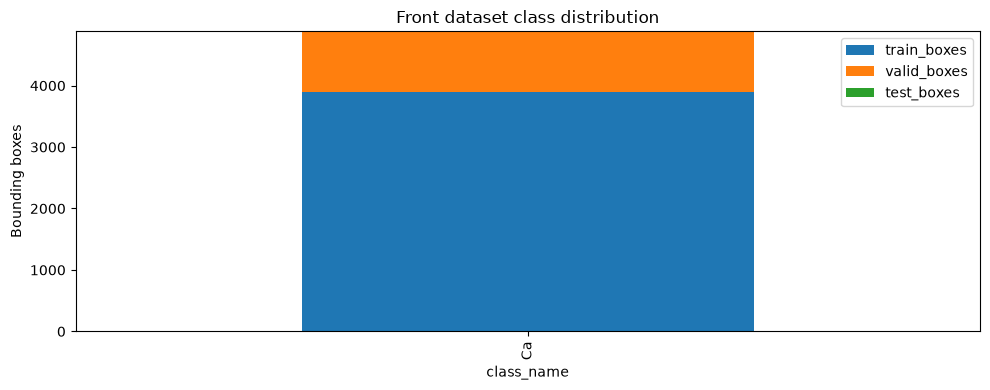

,mean,median,std,min,max,Q25,Q75
bbox_width,0.116644,0.116250,0.031932,0.018750,0.253125,0.094688,0.137500
bbox_height,0.130095,0.127396,0.024354,0.040625,0.248688,0.113573,0.144484
bbox_area,0.015296,0.014554,0.005452,0.001143,0.048504,0.011742,0.018169


BBox count/image statistics:


count    1269.000000
mean        3.847912
std         1.575554
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         8.000000
dtype: float64

In [10]:
import matplotlib.pyplot as plt
class_distribution = pd.DataFrame({'class_id': range(NC), 'class_name': [CLASS_NAMES[index] for index in range(NC)]})
for split in ('train', 'valid', 'test'):
    counts = boxes_df.loc[boxes_df['split'] == split, 'class_id'].value_counts() if len(boxes_df) else pd.Series(dtype=int)
    class_distribution[f'{split}_boxes'] = class_distribution['class_id'].map(counts).fillna(0).astype(int)
class_distribution['total_boxes'] = class_distribution[['train_boxes', 'valid_boxes', 'test_boxes']].sum(axis=1)
display(class_distribution)
if class_distribution['total_boxes'].sum() > 0:
    class_distribution.set_index('class_name')[['train_boxes', 'valid_boxes', 'test_boxes']].plot(kind='bar', stacked=True, figsize=(10, 4), title='Front dataset class distribution')
    plt.ylabel('Bounding boxes'); plt.tight_layout(); plt.show()
diagnostic_columns = ['bbox_width', 'bbox_height', 'bbox_area']
bbox_diagnostics = boxes_df[diagnostic_columns].describe(percentiles=[0.25, 0.5, 0.75]).T if len(boxes_df) else pd.DataFrame()
if len(bbox_diagnostics):
    bbox_diagnostics = bbox_diagnostics.rename(columns={'25%': 'Q25', '50%': 'median', '75%': 'Q75', 'mean': 'mean', 'std': 'std', 'min': 'min', 'max': 'max'})
    display(bbox_diagnostics[['mean', 'median', 'std', 'min', 'max', 'Q25', 'Q75']])
bbox_count_per_image = boxes_df.groupby(['split', 'label_path']).size() if len(boxes_df) else pd.Series(dtype=int)
print('BBox count/image statistics:')
display(bbox_count_per_image.describe())
bbox_warnings = []
if len(boxes_df) and (boxes_df['bbox_area'] < 0.0001).any(): bbox_warnings.append('Extremely small bbox area (<0.0001) detected.')
if len(boxes_df) and (boxes_df['bbox_area'] > 0.9).any(): bbox_warnings.append('Extremely large bbox area (>0.9) detected.')
for warning in bbox_warnings: print(f'WARNING: {warning}')

## 11. Duplicate diagnostics

In [11]:
def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()
image_hash_rows = []
all_images = [(split, path) for split, files in split_files.items() for path in files['images']]
for index, (split, path) in enumerate(all_images, 1):
    if index % 100 == 0 or index == len(all_images): print(f'Hashing images: {index}/{len(all_images)}')
    image_hash_rows.append({'sha256': sha256_file(path), 'split': split, 'relative_path': str(path.relative_to(DATASET_ROOT))})
image_hashes = pd.DataFrame(image_hash_rows)
duplicate_rows = []
for digest, group in image_hashes.groupby('sha256'):
    if len(group) > 1:
        paths, splits = group['relative_path'].tolist(), sorted(group['split'].unique())
        duplicate_rows.append({'sha256': digest, 'file_count': len(group), 'splits': '|'.join(splits), 'cross_split': len(splits) > 1, 'relative_paths': '|'.join(paths)})
duplicates_df = pd.DataFrame(duplicate_rows, columns=['sha256', 'file_count', 'splits', 'cross_split', 'relative_paths'])
print(f'Duplicate image hashes: {len(duplicates_df)}')
print(f'Cross-split duplicates: {int(duplicates_df["cross_split"].sum()) if len(duplicates_df) else 0}')
display(duplicates_df.head(20))
print('TANK_METADATA = NOT_AVAILABLE')

Hashing images: 100/1269
Hashing images: 200/1269
Hashing images: 300/1269
Hashing images: 400/1269
Hashing images: 500/1269
Hashing images: 600/1269
Hashing images: 700/1269
Hashing images: 800/1269
Hashing images: 900/1269
Hashing images: 1000/1269
Hashing images: 1100/1269
Hashing images: 1200/1269
Hashing images: 1269/1269
Duplicate image hashes: 0
Cross-split duplicates: 0


,sha256,file_count,splits,cross_split,relative_paths


TANK_METADATA = NOT_AVAILABLE


## 12. Save evidence

In [12]:
LOG_DETECTION_DIR = PROJECT_ROOT / 'logs' / 'detection'
LOG_DATA_DIR = PROJECT_ROOT / 'logs' / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'detection'
for directory in (LOG_DETECTION_DIR, LOG_DATA_DIR, RESULTS_DIR): directory.mkdir(parents=True, exist_ok=True)
OUTPUTS = {
 'audit_log': LOG_DETECTION_DIR / 'dataset_audit.log',
 'summary_csv': RESULTS_DIR / 'front_dataset_audit_summary.csv',
 'class_csv': RESULTS_DIR / 'front_class_distribution.csv',
 'errors_csv': RESULTS_DIR / 'front_label_errors.csv',
 'boundary_warnings_csv': RESULTS_DIR / 'front_boundary_warnings.csv',
 'annotation_format_csv': RESULTS_DIR / 'front_annotation_format_summary.csv',
 'mixed_format_csv': RESULTS_DIR / 'front_mixed_format_files.csv',
 'duplicates_csv': RESULTS_DIR / 'front_duplicate_files.csv',
 'versions_csv': LOG_DATA_DIR / 'roboflow_versions.csv',
 'manifest_json': RESULTS_DIR / 'front_dataset_manifest.json',
}
split_summary.to_csv(OUTPUTS['summary_csv'], index=False)
class_distribution.to_csv(OUTPUTS['class_csv'], index=False)
label_errors_df.to_csv(OUTPUTS['errors_csv'], index=False)
boundary_warnings_df.to_csv(OUTPUTS['boundary_warnings_csv'], index=False)
annotation_format_summary.to_csv(OUTPUTS['annotation_format_csv'], index=False)
mixed_format_files_df.to_csv(OUTPUTS['mixed_format_csv'], index=False)
duplicates_df.to_csv(OUTPUTS['duplicates_csv'], index=False)
versions_row = pd.DataFrame([{'camera': 'front', 'workspace': WORKSPACE_ID, 'project': PROJECT_ID, 'version': VERSION_NUMBER, 'format': EXPORT_FORMAT, 'local_path': str(DATASET_ROOT.relative_to(PROJECT_ROOT)), 'download_datetime': DOWNLOAD_DATETIME}])
if OUTPUTS['versions_csv'].exists():
    prior_versions = pd.read_csv(OUTPUTS['versions_csv'])
    prior_versions = prior_versions[prior_versions['camera'].str.lower() != 'front'] if 'camera' in prior_versions else prior_versions
    versions_row = pd.concat([prior_versions, versions_row], ignore_index=True)
versions_row.to_csv(OUTPUTS['versions_csv'], index=False)
manifest = {'dataset_source': 'roboflow', 'workspace': WORKSPACE_ID, 'project': PROJECT_ID, 'version': VERSION_NUMBER, 'export_format': EXPORT_FORMAT, 'download_date': DOWNLOAD_DATETIME, 'split_counts': split_summary.to_dict(orient='records'), 'annotation_format_counts': annotation_format_summary.to_dict(orient='records'), 'class_names': CLASS_NAMES, 'total_images': int(split_summary['n_images'].sum()), 'total_boxes': int(split_summary['n_boxes'].sum()), 'dataset_local_path': str(DATASET_ROOT.relative_to(PROJECT_ROOT)), 'data_yaml_sha256': sha256_file(DATA_YAML_PATH)}
OUTPUTS['manifest_json'].write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding='utf-8')
for name, path in OUTPUTS.items():
    if name != 'audit_log': print(f'Created {path.relative_to(PROJECT_ROOT)} ({path.stat().st_size} bytes)')

Created results/detection/front_dataset_audit_summary.csv (235 bytes)
Created results/detection/front_class_distribution.csv (88 bytes)
Created results/detection/front_label_errors.csv (101 bytes)
Created results/detection/front_boundary_warnings.csv (92 bytes)
Created results/detection/front_annotation_format_summary.csv (117 bytes)
Created results/detection/front_mixed_format_files.csv (62 bytes)
Created results/detection/front_duplicate_files.csv (52 bytes)
Created logs/data/roboflow_versions.csv (145 bytes)
Created results/detection/front_dataset_manifest.json (1453 bytes)


## 13. Final summary

In [13]:
total_missing = int(split_summary['n_missing_labels'].sum())
total_orphans = int(split_summary['n_orphan_labels'].sum())
total_empty = int(split_summary['n_empty_labels'].sum())
true_invalid_labels = len(label_errors_df)
boundary_warning_count = len(boundary_warnings_df)
boundary_warning_images = int(boundary_warnings_df['label_path'].nunique()) if boundary_warning_count else 0
bbox_rows = int(annotation_format_summary['bbox_rows'].sum())
polygon_rows = int(annotation_format_summary['polygon_rows'].sum())
bbox_files = int(annotation_format_summary['bbox_files'].sum())
polygon_files = int(annotation_format_summary['polygon_files'].sum())
mixed_format_files = int(annotation_format_summary['mixed_format_files'].sum())
annotation_formats = [name for name, count in (('bbox', bbox_rows), ('polygon', polygon_rows)) if count]
cross_split_duplicates = int(duplicates_df['cross_split'].sum()) if len(duplicates_df) else 0
warnings = []
if 'test' not in SPLITS: warnings.append('Optional test split is absent.')
if total_missing: warnings.append(f'Missing labels: {total_missing}')
if total_orphans: warnings.append(f'Orphan labels: {total_orphans}')
if total_empty: warnings.append(f'Empty labels: {total_empty}')
if boundary_warning_count: warnings.append('Boundary warnings originate from valid YOLO labels whose box extents cross image boundaries; original annotations are preserved.')
if bbox_files and polygon_files: warnings.append('Dataset contains separate bbox-only and polygon-only label files; original annotations are preserved.')
if mixed_format_files: warnings.append(f'IMPORTANT — mixed bbox/polygon label files require USER review before training: {mixed_format_files}')
if len(duplicates_df): warnings.append(f'Duplicate image hashes: {len(duplicates_df)}')
if cross_split_duplicates: warnings.append(f'IMPORTANT — cross-split duplicates: {cross_split_duplicates}')
warnings.extend(bbox_warnings)
fatal_conditions = {'true_invalid_labels': true_invalid_labels, 'corrupt_images': len(corrupt_images_df)}
checkpoint_result = 'FAIL' if any(fatal_conditions.values()) else ('PASS_WITH_WARNING' if warnings else 'PASS')
runtime = time.perf_counter() - START_TIME
summary = {'experiment_id': EXPERIMENT_ID, 'workspace': WORKSPACE_ID, 'project': PROJECT_ID, 'version': VERSION_NUMBER, 'format': EXPORT_FORMAT, 'dataset_root': str(DATASET_ROOT.relative_to(PROJECT_ROOT)), 'train_images': int(split_summary.loc[split_summary.split == 'train', 'n_images'].sum()), 'train_boxes': int(split_summary.loc[split_summary.split == 'train', 'n_boxes'].sum()), 'valid_images': int(split_summary.loc[split_summary.split == 'valid', 'n_images'].sum()), 'valid_boxes': int(split_summary.loc[split_summary.split == 'valid', 'n_boxes'].sum()), 'test_images': int(split_summary.loc[split_summary.split == 'test', 'n_images'].sum()), 'test_boxes': int(split_summary.loc[split_summary.split == 'test', 'n_boxes'].sum()), 'classes': CLASS_NAMES, 'annotation_formats': annotation_formats, 'bbox_rows': bbox_rows, 'polygon_rows': polygon_rows, 'bbox_files': bbox_files, 'polygon_files': polygon_files, 'mixed_format_files': mixed_format_files, 'missing_labels': total_missing, 'orphan_labels': total_orphans, 'empty_labels': total_empty, 'true_invalid_labels': true_invalid_labels, 'boundary_warnings': boundary_warning_count, 'boundary_warning_images': boundary_warning_images, 'corrupt_images': len(corrupt_images_df), 'cross_split_duplicates': cross_split_duplicates, 'runtime_sec': round(runtime, 3), 'checkpoint_result': checkpoint_result, 'output_files': [str(path.relative_to(PROJECT_ROOT)) for path in OUTPUTS.values()], 'warnings': warnings, 'next_step': 'USER reviews Notebook 02 results; do not begin training without explicit approval.'}
audit_lines = ['FINAL SUMMARY'] + [f'{key}: {value}' for key, value in summary.items()]
OUTPUTS['audit_log'].write_text('\n'.join(audit_lines) + '\n', encoding='utf-8')
print('\n'.join(audit_lines))
print(f'Created {OUTPUTS["audit_log"].relative_to(PROJECT_ROOT)} ({OUTPUTS["audit_log"].stat().st_size} bytes)')
display(pd.DataFrame([summary]))

FINAL SUMMARY
experiment_id: FRONT_DATASET_AUDIT_001
workspace: phys-hus
project: fish_front_detection
version: 1
format: yolov8
dataset_root: data/roboflow/front_detect_v1
train_images: 1015
train_boxes: 3888
valid_images: 254
valid_boxes: 995
test_images: 0
test_boxes: 0
classes: {0: 'Ca'}
annotation_formats: ['bbox', 'polygon']
bbox_rows: 4832
polygon_rows: 51
bbox_files: 1257
polygon_files: 12
mixed_format_files: 0
missing_labels: 0
orphan_labels: 0
empty_labels: 0
true_invalid_labels: 0
boundary_warnings: 0
boundary_warning_images: 0
corrupt_images: 0
cross_split_duplicates: 0
runtime_sec: 5.698
checkpoint_result: PASS_WITH_WARNING
output_files: ['logs/detection/dataset_audit.log', 'results/detection/front_dataset_audit_summary.csv', 'results/detection/front_class_distribution.csv', 'results/detection/front_label_errors.csv', 'results/detection/front_boundary_warnings.csv', 'results/detection/front_annotation_format_summary.csv', 'results/detection/front_mixed_format_files.csv', '

,experiment_id,workspace,project,version,format,dataset_root,train_images,train_boxes,valid_images,valid_boxes,...,true_invalid_labels,boundary_warnings,boundary_warning_images,corrupt_images,cross_split_duplicates,runtime_sec,checkpoint_result,output_files,warnings,next_step
0,FRONT_DATASET_AUDIT_001,phys-hus,fish_front_detection,1,yolov8,data/roboflow/front_detect_v1,1015,3888,254,995,...,0,0,0,0,0,5.698,PASS_WITH_WARNING,"[logs/detection/dataset_audit.log, results/det...","[Optional test split is absent., Dataset conta...",USER reviews Notebook 02 results; do not begin...
